# IMPORTS

In [1]:
%load_ext autoreload

import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import numpy as np
import jax.numpy as jnp

import tol_colors as tc
import matplotlib.pyplot as plt
import plotting_tools.basic_plotting_tools as pts
colors = pts.set_plot_style(default_cmap=tc.sunset)
%matplotlib widget

In [2]:
import differential_geometry.manifolds as manifolds
import differential_geometry.aux_manifolds as aux_manifolds
import plotting_tools.plot_manifolds as plot_manifolds

from scipy.spatial import Delaunay
import differential_geometry.charts as charts
import differential_geometry.aux_charts as aux_charts
import plotting_tools.plot_charts as plot_charts

import differential_geometry.functions as functions
import plotting_tools.plot_functions as plot_functions

import differential_geometry.covectors as covectors
import plotting_tools.plot_covectors as plot_covectors

import differential_geometry.fields as fields
import plotting_tools.plot_fields as plot_fields

# 2D-mfd embedded in 3D

Same manifold, charts, base point and scalar field $f$ as in `2_4_cotangent_space.ipynb`.
On top of that, two **vector fields**, i.e. two smooth sections of the tangent bundle,
$\mathcal{X}, \mathcal{Y} \in \Gamma T\mathcal{M}$ with $\pi \circ \mathcal{X} = \mathbb{I}_\mathcal{M}$:

- $\mathcal{X}$, a rotation around the origin of parameter space;
- $\mathcal{Y}$, whose component functions are *constant* in the chart $\mathscr{X}$ — but, as the
  panels below show, not in $\mathscr{Y}$.

The figures show, in this order: a field as a section (one vector picked inside each fibre
$T_p\mathcal{M}$), the component functions $X^i \in C^\infty(\mathcal{U})$ of the same two fields
seen in the two charts, the chart-induced frames $\partial\mathscr{X}_i$ and
$\partial\mathscr{Y}_i$, the $C^\infty(\mathcal{M})$-module operations $\oplus_\Gamma$ and
$\odot_\Gamma$, and the action $\mathcal{X}\lfloor f \rceil \in C^\infty(\mathcal{M})$.

One caveat when reading the chart panels: the arrows there are **component functions**, not
lengths on the manifold. Without a metric there is no intrinsic notion of the length of a tangent
vector, so the arrows are drawn normalized and the comparison between charts should be made on
directions and on the printed numbers, not on sizes.

In [3]:
manifold = manifolds.Manifold(
    name=r"$\mathcal{M}$", dim=2, ambient_dim=3,
    embedding_func=aux_manifolds.factory_surface_embedding_gaussian_eggs(
        amplitude=1.0, center=(0.0, 0.0), sigma=(jnp.pi, jnp.pi)),
)

# === Charts: the same two charts as in the previous notebooks ===
center_V = jnp.array([0.7, 0.3])
axes_V = (1.4, 0.9)
x_center_polar, y_center_polar = -1., -1.
polar_center = (x_center_polar, y_center_polar)

lambdas = jnp.linspace(0, 2 * jnp.pi, 600)
boundary_V = aux_charts.boundary_ellipse_in_param_space(lambdas, center=center_V, axes=axes_V)
chart_V = charts.Chart(
    name="V", manifold=manifold, boundary=jnp.array(boundary_V),
    chart_map=lambda params: aux_charts.polar_chart_map(params, center=polar_center),
    inverse_chart_map=lambda chart_coords: aux_charts.inverse_polar_chart_map(chart_coords, center=polar_center),
    region_sampler=aux_charts.polar_region_sampler_from_boundary(
        jnp.array(boundary_V), center=jnp.array(polar_center)
    )
)

center_U = jnp.array([0.1, -0.7])
axes_U = (0.9, 1.5)
boundary_U = aux_charts.boundary_ellipse_in_param_space(lambdas, center=center_U, axes=axes_U)
chart_U = charts.Chart(
    name="U", manifold=manifold, boundary=jnp.array(boundary_U),
    chart_map=aux_charts.cartesian_chart_map,
    inverse_chart_map=aux_charts.inverse_cartesian_chart_map,
    region_sampler=aux_charts.polar_region_sampler_from_boundary(
        jnp.array(boundary_U), center=jnp.array(polar_center)
    )
)

ERROR:2026-09-22 22:36:02,045:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/dlopez/.miniconda3/envs/diff_geom/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 197, in _version_check
    version = get_version()
RuntimeError: jaxlib/cuda/versions_helpers.cc:81: operation cusparseGetProperty(MAJOR_VERSION, &major) failed: The cuSPARSE library was not found.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/dlopez/.miniconda3/envs/diff_geom/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/dlopez/.miniconda3/envs/diff_geom/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/dlopez/.miniconda3/envs/

In [4]:
# === Scalar field f and base point p (as in the cotangent notebook) ===

def scalar_field_f(params):
    """Height weighted by the ambient radius."""
    point_in_M = manifold.embedding_func(params)
    return point_in_M[2] * jnp.sqrt(point_in_M[0]**2 + point_in_M[1]**2 + 2.)

function_f = functions.Function(manifold=manifold, function_parametric=scalar_field_f)

p_param = jnp.array([jnp.pi / 4, -jnp.pi / 8])
p_in_M = manifold.embed(p_param)

# === Two vector fields ===
# A field is given through its components in parameter space; the component
# functions X^i in a chart-induced basis are computed by the field itself.
# The section property (pi o X = identity) is automatic here: the field assigns a
# vector to the very point at which it is evaluated.

def circular_vector_field(params):
    """X: rotation around the origin of parameter space."""
    return jnp.array([-params[1], params[0]])

def constant_vector_field(params):
    """Y: constant components in the cartesian chart (not in the polar one!)."""
    return jnp.array([0.0, 1.0])

field_X = fields.VectorField(manifold=manifold, vector_function=circular_vector_field)
field_Y = fields.VectorField(manifold=manifold, vector_function=constant_vector_field)

# === C^inf(M)-module operations and action on the scalar field ===
field_sum = field_X.add(field_Y)                          # X (+)_Gamma Y
field_scaled = field_X.multiply_by_function(function_f)   # f (.)_Gamma X
action_X_f = field_X.action_on_function(function_f)       # X|_f_| in C^inf(M)

# === Chart-induced frames over each chart domain ===
frame_U = fields.chart_induced_frame(chart_U)   # [ dX_1, dX_2 ]
frame_V = fields.chart_induced_frame(chart_V)   # [ dY_1, dY_2 ]

xmin, xmax = jnp.array([-jnp.pi, jnp.pi]) * jnp.pi/3
ymin, ymax = jnp.array([-jnp.pi, jnp.pi]) * jnp.pi/3

color_X, color_Y = colors[3], colors[1]

## Components, module operations and the action on functions

$$X^i(p) = (d\mathscr{X}^i)_p\big(\mathcal{X}(p)\big), \qquad
X^i = \left(J_{\mathcal{U}\mathcal{V}}\right)^i_{\ j}\, Y^j, \qquad
\partial\mathscr{Y}_j = \left(J_{\mathcal{U}\mathcal{V}}\right)^i_{\ j}\, \partial\mathscr{X}_i, \qquad
\mathcal{X}\lfloor f \rceil(p) = (df)_p\big(\mathcal{X}(p)\big) = X^i(p)\, \mathtt{x}_i(p).$$

The last identity ties this notebook to the cotangent one: the action of a vector field on a
scalar field is the pairing of the differential with the field, and it can be evaluated in either
chart or chart-free.

In [5]:
# === Component functions at the base point p ===
X_in_U = field_X.components_in_chart(chart_U, p_param)   # X^i(p)
X_in_V = field_X.components_in_chart(chart_V, p_param)   # Y^i(p)
Y_in_U = field_Y.components_in_chart(chart_U, p_param)
Y_in_V = field_Y.components_in_chart(chart_V, p_param)

J_UV = covectors.chart_transition_jacobian(chart_U, chart_V, p_param)
J_VU = covectors.chart_transition_jacobian(chart_V, chart_U, p_param)

print("=== component functions at p ===")
print("X :  in U =", X_in_U, "   in V =", X_in_V)
print("Y :  in U =", Y_in_U, "   in V =", Y_in_V)

print("\n=== transformation of the component functions (contravariant) ===")
print("(J_VU)^i_j X^j =", J_VU @ X_in_U, " vs  X^i in V =", X_in_V)
print("(J_UV)^i_j Y^j =", J_UV @ X_in_V, " vs  X^i in U =", X_in_U)

print("\n=== chart-induced frames ===")
print("dX_1, dX_2 in the chart U basis :",
      frame_U[0].components_in_chart(chart_U, p_param),
      frame_U[1].components_in_chart(chart_U, p_param))
print("dY_1, dY_2 in the chart U basis :",
      frame_V[0].components_in_chart(chart_U, p_param),
      frame_V[1].components_in_chart(chart_U, p_param))
print("columns of J_UV (the same thing) :", J_UV[:, 0], J_UV[:, 1])

print("\n=== expansion X|_U = X^i dX_i at p (parameter components) ===")
expansion = sum(
    float(X_in_U[i]) * frame_U[i].evaluate_in_param_space(p_param) for i in range(manifold.dim)
)
print(expansion, " vs  X(p) =", field_X.evaluate_in_param_space(p_param))

print("\n=== C^inf(M)-module operations at p ===")
f_at_p = function_f.evaluate_in_param_space(p_param[None, :])[0]
print("X(p) + Y(p) =", field_X.evaluate_in_param_space(p_param) + field_Y.evaluate_in_param_space(p_param),
      " vs  (X (+)_Gamma Y)(p) =", field_sum.evaluate_in_param_space(p_param))
print("f(p) * X(p) =", f_at_p * field_X.evaluate_in_param_space(p_param),
      " vs  (f (.)_Gamma X)(p) =", field_scaled.evaluate_in_param_space(p_param))

print("\n=== action on the scalar field ===")
covector_df = covectors.Covector(function=function_f, param_point=p_param)
print("X|_f_|(p)              =", action_X_f.evaluate_in_param_space(p_param[None, :])[0])
print("(df)_p(X(p)) in chart U =", covector_df.evaluate_on_vector_in_chart(chart_U, X_in_U))
print("(df)_p(X(p)) in chart V =", covector_df.evaluate_on_vector_in_chart(chart_V, X_in_V))

=== component functions at p ===
X :  in U = [0.3926991 0.7853982]    in V = [0.62470084 0.3272247 ]
Y :  in U = [0. 1.]    in V = [0.3220289  0.50201535]

=== transformation of the component functions (contravariant) ===
(J_VU)^i_j X^j = [0.62470084 0.3272247 ]  vs  X^i in V = [0.62470084 0.3272247 ]
(J_UV)^i_j Y^j = [0.3926991 0.7853981]  vs  X^i in U = [0.3926991 0.7853982]

=== chart-induced frames ===
dX_1, dX_2 in the chart U basis : [1. 0.] [0. 1.]
dY_1, dY_2 in the chart U basis : [0.9467299  0.32202893] [-0.60730094  1.7853982 ]
columns of J_UV (the same thing) : [0.9467299  0.32202893] [-0.60730094  1.7853982 ]

=== expansion X|_U = X^i dX_i at p (parameter components) ===
[0.3926991 0.7853982]  vs  X(p) = [0.3926991 0.7853982]

=== C^inf(M)-module operations at p ===
X(p) + Y(p) = [0.3926991 1.7853982]  vs  (X (+)_Gamma Y)(p) = [0.3926991 1.7853982]
f(p) * X(p) = [1.0393581 2.0787163]  vs  (f (.)_Gamma X)(p) = [1.0393581 2.0787163]

=== action on the scalar field ===
X|_f_|(

## plot mfd

A vector field is a **section of the tangent bundle**: over each base point sits a fibre
$T_p\mathcal{M}$, and the field picks exactly one vector inside it. Three fibres are drawn as
patches of the tangent plane, with the vector selected by $\mathcal{X}$ inside each of them; the
small arrows are the same field pushed forward to the ambient space over a grid of base points.

/home/dlopez/tmp/pip-tmp/ipykernel_438487/632431456.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


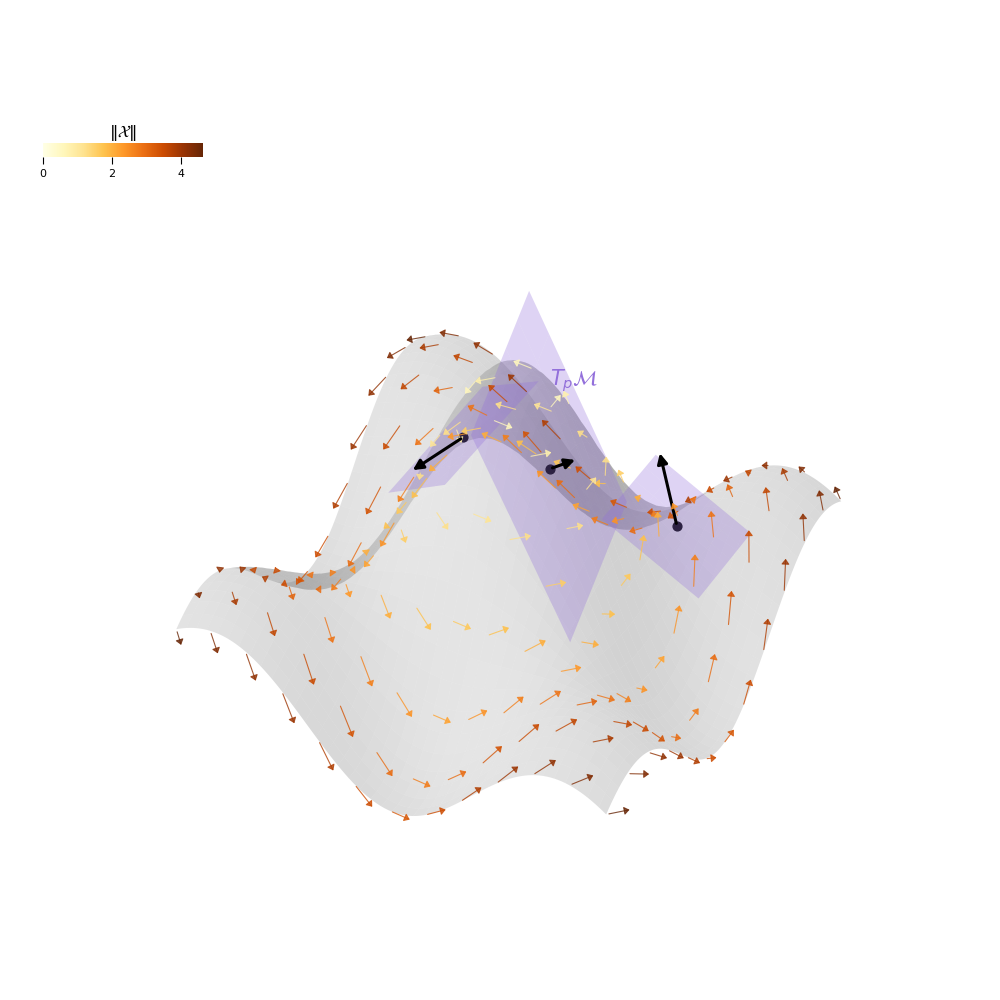

In [6]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

plot_manifolds.plot_manifold(
    ax=ax, manifold=manifold, resolution=120, xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax,
    color=colors[-1], alpha=0.30, edgecolor="none", label=None
)

# === The field over the manifold (pushforward to the ambient space) ===
plot_fields.plot_vector_field_on_manifold(
    ax=ax, field=field_X, grid_resolution=13, xlim=(xmin, xmax), ylim=(ymin, ymax),
    vector_scale=0.35, normalize=True, colormap="YlOrBr", label=r"$\|\mathcal{X}\|$",
    inset_position=(0.02, 0.86), inset_size=(1.6, 0.14)
)

# === A few fibres T_pM, with the vector the section picks inside each of them ===
section_points = jnp.array([[jnp.pi/4, -jnp.pi/8], [-1.3, 0.9], [1.7, 1.5]])
plot_fields.plot_field_section_on_manifold(
    ax=ax, field=field_X, param_points=section_points, plane_size=0.75,
    plane_color="mediumpurple", plane_alpha=0.30, vector_scale=0.5, color="black",
    linewidth=2.2, labels=[r"$T_p\mathcal{M}$", None, None], label_fontsize=15,
    label_offset=(0.0, 0.0, 0.55)
)

ax.view_init(elev=45.0, azim=-60.0)
plt.tight_layout()
plt.show()

## Chart $(\mathcal{U}, \mathscr{X})$

The two fields seen through the cartesian chart: $\mathcal{X}$ circulates around the origin,
$\mathcal{Y}$ has constant components $(0, 1)$ everywhere.

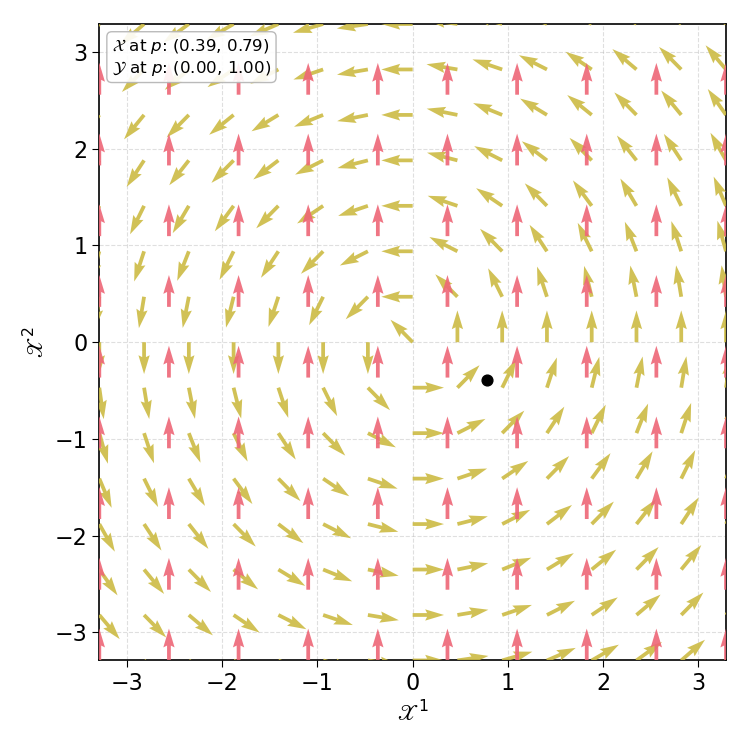

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 7.5))

xlim, ylim = (xmin, xmax), (ymin, ymax)
span = float(xlim[1] - xlim[0])

plot_fields.plot_field_in_chart(
    ax=ax, field=field_X, chart=chart_U, xlim=xlim, ylim=ylim, grid_resolution=15,
    vector_scale=0.05*span, normalize=True, color=color_X, width=0.006, zorder=3
)
plot_fields.plot_field_in_chart(
    ax=ax, field=field_Y, chart=chart_U, xlim=xlim, ylim=ylim, grid_resolution=10,
    vector_scale=0.05*span, normalize=True, color=color_Y, width=0.006, zorder=3
)

# === Base point and component functions there ===
p_in_chart = np.asarray(chart_U.map_to_chart(p_param))
ax.scatter(p_in_chart[0], p_in_chart[1], color="black", s=60, zorder=6)

components_X = np.asarray(field_X.components_in_chart(chart_U, p_param))
components_Y = np.asarray(field_Y.components_in_chart(chart_U, p_param))
ax.text(
    0.02, 0.98,
    r"$\mathcal{X}$ at $p$: " + "({:.2f}, {:.2f})".format(components_X[0], components_X[1]) + "\n"
    + r"$\mathcal{Y}$ at $p$: " + "({:.2f}, {:.2f})".format(components_Y[0], components_Y[1]),
    transform=ax.transAxes, va="top", ha="left", fontsize=12,
    bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.9)
)

ax.set(xlim=xlim, ylim=ylim, xlabel=r"$\mathscr{X}^1$", ylabel=r"$\mathscr{X}^2$")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Chart $(\mathcal{V}, \mathscr{Y})$

The very same two fields, now through the polar chart. Neither of them looks like it did in
$\mathscr{X}$: in particular the components of $\mathcal{Y}$ are no longer constant, which is a
good reminder that "constant components" is a statement about a chart and not about the field.
The window starts at $\mathscr{Y}^1 = 0.5$ because the polar chart degenerates as
$\mathscr{Y}^1 \to 0$.

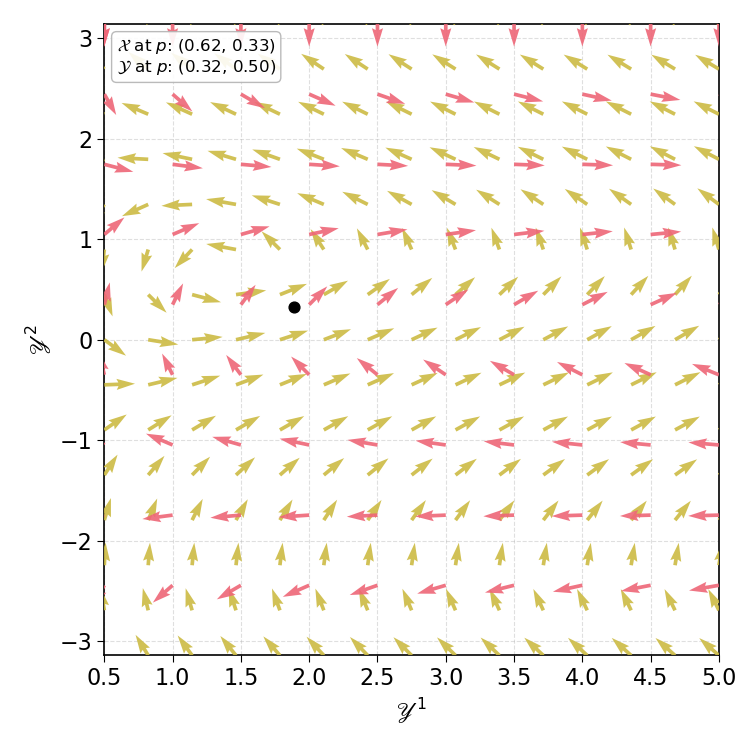

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 7.5))

xlim, ylim = (0.5, 5.0), (-jnp.pi, jnp.pi)
span = float(xlim[1] - xlim[0])

plot_fields.plot_field_in_chart(
    ax=ax, field=field_X, chart=chart_V, xlim=xlim, ylim=ylim, grid_resolution=15,
    vector_scale=0.05*span, normalize=True, color=color_X, width=0.006, zorder=3
)
plot_fields.plot_field_in_chart(
    ax=ax, field=field_Y, chart=chart_V, xlim=xlim, ylim=ylim, grid_resolution=10,
    vector_scale=0.05*span, normalize=True, color=color_Y, width=0.006, zorder=3
)

# === Base point and component functions there ===
p_in_chart = np.asarray(chart_V.map_to_chart(p_param))
ax.scatter(p_in_chart[0], p_in_chart[1], color="black", s=60, zorder=6)

components_X = np.asarray(field_X.components_in_chart(chart_V, p_param))
components_Y = np.asarray(field_Y.components_in_chart(chart_V, p_param))
ax.text(
    0.02, 0.98,
    r"$\mathcal{X}$ at $p$: " + "({:.2f}, {:.2f})".format(components_X[0], components_X[1]) + "\n"
    + r"$\mathcal{Y}$ at $p$: " + "({:.2f}, {:.2f})".format(components_Y[0], components_Y[1]),
    transform=ax.transAxes, va="top", ha="left", fontsize=12,
    bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.9)
)

ax.set(xlim=xlim, ylim=ylim, xlabel=r"$\mathscr{Y}^1$", ylabel=r"$\mathscr{Y}^2$")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Chart-induced frames

The frames $\{\partial\mathscr{X}_i\}$ and $\{\partial\mathscr{Y}_i\}$, both drawn in the
coordinates of the chart $\mathscr{X}$, so that the basis transformation
$\partial\mathscr{Y}_j = (J_{\mathcal{U}\mathcal{V}})^i_{\ j}\, \partial\mathscr{X}_i$ can be read
off directly. Each frame is a local object: the polar one is not even defined at the centre of the
polar chart, marked with a cross — a mild version of the remark that a module need not admit a
global basis.

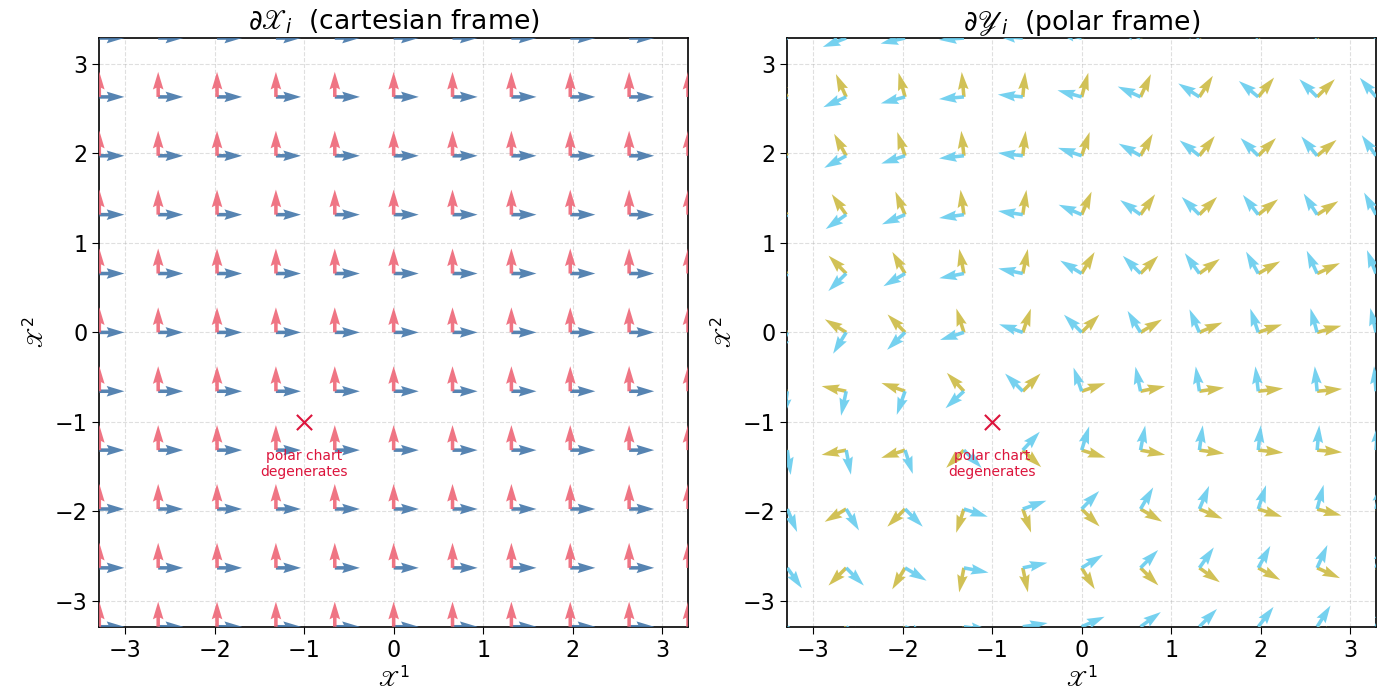

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

panels = [
    (frame_U, r"$\partial \mathscr{X}_i$  (cartesian frame)", (colors[0], colors[1])),
    (frame_V, r"$\partial \mathscr{Y}_i$  (polar frame)", (colors[3], colors[4])),
]

for ax, (frame, title, frame_colors) in zip(axes, panels):
    for frame_field, frame_color in zip(frame, frame_colors):
        plot_fields.plot_field_in_chart(
            ax=ax, field=frame_field, chart=chart_U, xlim=(xmin, xmax), ylim=(ymin, ymax),
            grid_resolution=11, vector_scale=0.28, normalize=True, color=frame_color, width=0.006
        )

    ax.scatter(*polar_center, marker="x", color="crimson", s=120, zorder=6)
    ax.text(polar_center[0], polar_center[1] - 0.3, "polar chart\ndegenerates",
            color="crimson", ha="center", va="top", fontsize=10)

    ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax), title=title,
           xlabel=r"$\mathscr{X}^1$", ylabel=r"$\mathscr{X}^2$")
    ax.set_aspect("equal")
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## The $C^\infty(\mathcal{M})$-module $\Gamma T\mathcal{M}$

Here the arrows are drawn at **true scale** (no normalization) and with the same scale factor in
the four panels, so that the two operations can actually be seen: $\mathcal{X} \oplus_\Gamma
\mathcal{Y}$ displaces the centre of the swirl, and $f \odot_\Gamma \mathcal{X}$ stretches,
shrinks and — where $f$ changes sign — reverses the arrows, pointwise. That is the whole
difference between a module and a vector space: the scaling factor is a *function*, not a number.

/home/dlopez/tmp/pip-tmp/ipykernel_438487/3103677675.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


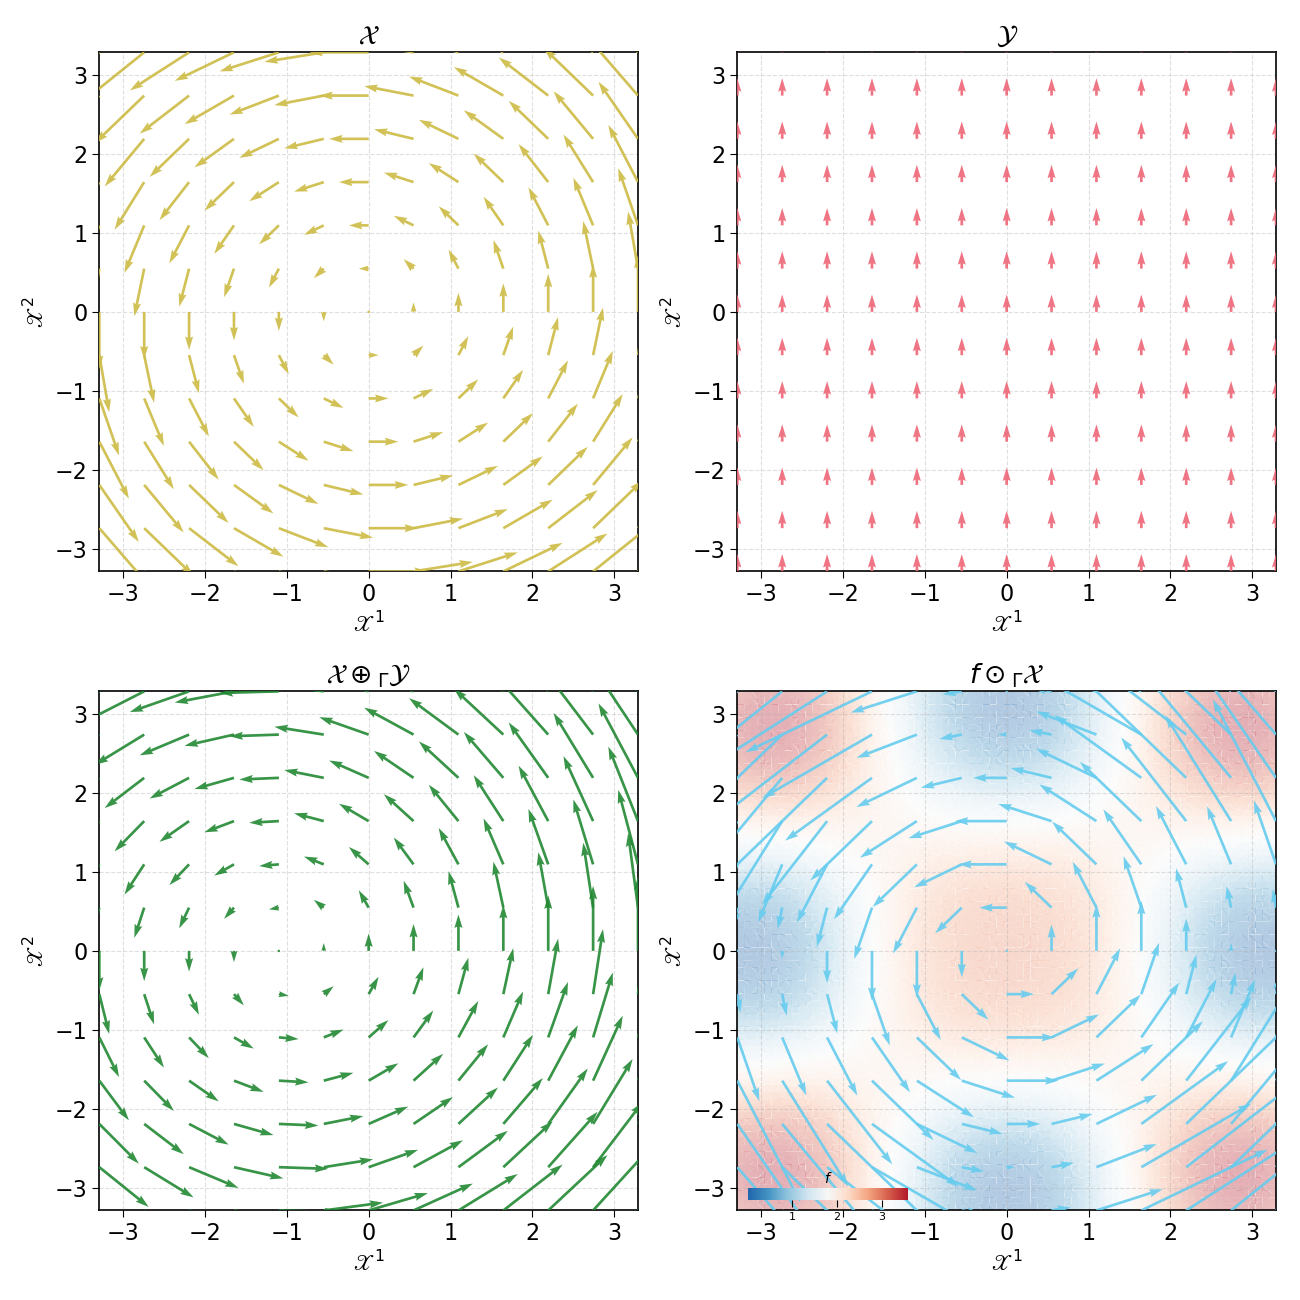

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 13))

# background sampling for the scalar field f
grid = jnp.linspace(xmin, xmax, 80)
grid_x, grid_y = jnp.meshgrid(grid, grid)
param_points = jnp.stack([grid_x.ravel(), grid_y.ravel()], axis=-1)
simplices = Delaunay(np.asarray(param_points)).simplices
function_values = jnp.array(function_f.evaluate_in_param_space(param_points))

panels = [
    (field_X, r"$\mathcal{X}$", color_X, False),
    (field_Y, r"$\mathcal{Y}$", color_Y, False),
    (field_sum, r"$\mathcal{X} \oplus_\Gamma \mathcal{Y}$", colors[2], False),
    (field_scaled, r"$f \odot_\Gamma \mathcal{X}$", colors[4], True),
]

for ax, (field, title, color, show_function) in zip(axes.ravel(), panels):
    if show_function:
        plot_functions.plot_parametric_function_in_chart_coordinates(
            ax=ax, chart=chart_U, param_space_data=param_points, function_values=function_values,
            cmap=tc.BuRd, alpha=0.35, label=None, simplices=simplices, inset_colorbar=True,
            inset_position=(0.02, 0.02), inset_size=(1.6, 0.12),
            label_colorbar=r"$f$", label_colorbar_position="top"
        )
    plot_fields.plot_field_in_chart(
        ax=ax, field=field, chart=chart_U, xlim=(xmin, xmax), ylim=(ymin, ymax),
        grid_resolution=13, vector_scale=0.22, normalize=False, color=color, width=0.005
    )
    ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax), title=title,
           xlabel=r"$\mathscr{X}^1$", ylabel=r"$\mathscr{X}^2$")
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## Action on scalar fields

$\mathcal{X}\lfloor f \rceil$ is again an element of $C^\infty(\mathcal{M})$, so it can be plotted
exactly like any other scalar field. It is drawn here in the chart $\mathscr{X}$ as a colour map,
together with the level sets of $f$ (thin lines) and the field $\mathcal{X}$ itself: the value
vanishes wherever the field runs along a level set of $f$, and is positive or negative depending on
whether the field crosses towards larger or smaller values of $f$.

/home/dlopez/tmp/pip-tmp/ipykernel_438487/1130497599.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


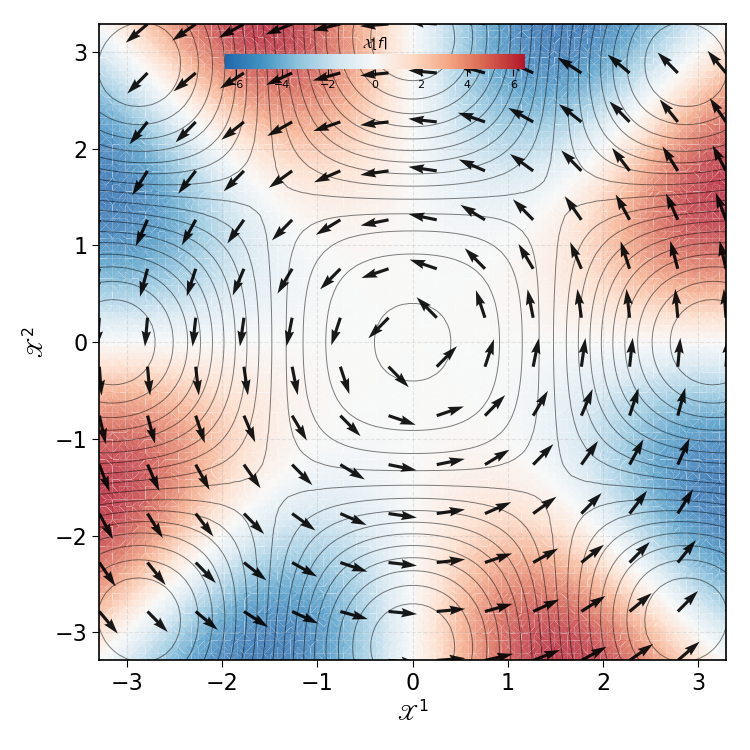

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 7.5))

grid = jnp.linspace(xmin, xmax, 96)
grid_x, grid_y = jnp.meshgrid(grid, grid)
param_points = jnp.stack([grid_x.ravel(), grid_y.ravel()], axis=-1)
simplices = Delaunay(np.asarray(param_points)).simplices
action_values = jnp.array(action_X_f.evaluate_in_param_space(param_points))

plot_functions.plot_parametric_function_in_chart_coordinates(
    ax=ax, chart=chart_U, param_space_data=param_points, function_values=action_values,
    cmap=tc.BuRd, alpha=0.8, label=None, simplices=simplices, inset_colorbar=True,
    inset_position=(0.2, 0.93), inset_size=(3.0, 0.15),
    label_colorbar=r"$\mathcal{X}\lfloor f \rceil$", label_colorbar_position="top"
)

plot_covectors.plot_function_level_sets_in_chart(
    ax=ax, chart=chart_U, function=function_f, param_space_data=param_points,
    levels=18, simplices=simplices, color="black", linewidths=0.7, alpha=0.5
)

plot_fields.plot_field_in_chart(
    ax=ax, field=field_X, chart=chart_U, xlim=(xmin, xmax), ylim=(ymin, ymax),
    grid_resolution=14, vector_scale=0.3, normalize=True, color="black", width=0.005, alpha=0.9
)

ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax),
       xlabel=r"$\mathscr{X}^1$", ylabel=r"$\mathscr{X}^2$")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()